# Mountain Car trying to go uphill

In [ ]:
# @title Setup (Gymnasium + imports)
!pip -q install gymnasium[classic-control] matplotlib numpy

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
np.random.seed(42)

In [ ]:
# @title Discretizer & epsilon schedule
class Discretizer:
    def __init__(self, low, high, bins=(18, 14)):
        self.low = np.array(low, dtype=np.float32)
        self.high = np.array(high, dtype=np.float32)
        self.bins = np.array(bins, dtype=np.int32)

    def transform(self, obs):
        # map obs from [low, high] -> [0, bins-1]
        ratios = (obs - self.low) / (self.high - self.low + 1e-8)
        idx = np.floor(ratios * self.bins).astype(int)
        idx = np.clip(idx, 0, self.bins - 1)
        return tuple(idx)

def epsilon_by_episode(ep, eps_start=1.0, eps_end=0.05, decay=0.995):
    # exponential decay per episode
    return max(eps_end, eps_start * (decay ** ep))

In [ ]:
# @title Train Q-learning on MountainCar-v0
env = gym.make("MountainCar-v0")  # Discrete actions: 0 left, 1 noop, 2 right
obs_low, obs_high = env.observation_space.low, env.observation_space.high

disc = Discretizer(obs_low, obs_high, bins=(18, 14))
n_actions = env.action_space.n
state_shape = tuple(disc.bins) + (n_actions,)

Q = np.zeros(state_shape, dtype=np.float32)

alpha = 0.10    # learning rate
gamma = 0.99    # discount
episodes = 5000
max_steps = 200

returns = []
moving = deque(maxlen=100)
best_return = -np.inf

for ep in range(episodes):
    obs, info = env.reset(seed=42 + ep)
    s = disc.transform(obs)
    eps = epsilon_by_episode(ep)

    ep_ret = 0.0
    for t in range(max_steps):
        # ε-greedy
        if np.random.rand() < eps:
            a = np.random.randint(n_actions)
        else:
            a = int(np.argmax(Q[s]))

        next_obs, r, terminated, truncated, info = env.step(a)
        s2 = disc.transform(next_obs)
        done = terminated or truncated

        # Q-learning update
        td_target = r + (0.0 if done else gamma * np.max(Q[s2]))
        Q[s + (a,)] += alpha * (td_target - Q[s + (a,)])

        s = s2
        ep_ret += r
        if done:
            break

    returns.append(ep_ret)
    moving.append(ep_ret)

    if (ep + 1) % 100 == 0:
        print(f"Ep {ep+1:4d} | eps={eps:0.3f} | avg_return(100)={np.mean(moving):6.2f}")

env.close()

Ep  100 | eps=0.609 | avg_return(100)=-200.00
Ep  200 | eps=0.369 | avg_return(100)=-200.00
Ep  300 | eps=0.223 | avg_return(100)=-200.00
Ep  400 | eps=0.135 | avg_return(100)=-200.00
Ep  500 | eps=0.082 | avg_return(100)=-197.98
Ep  600 | eps=0.050 | avg_return(100)=-198.77
Ep  700 | eps=0.050 | avg_return(100)=-199.26
Ep  800 | eps=0.050 | avg_return(100)=-197.77
Ep  900 | eps=0.050 | avg_return(100)=-195.51
Ep 1000 | eps=0.050 | avg_return(100)=-191.89
Ep 1100 | eps=0.050 | avg_return(100)=-192.20
Ep 1200 | eps=0.050 | avg_return(100)=-199.67
Ep 1300 | eps=0.050 | avg_return(100)=-195.38
Ep 1400 | eps=0.050 | avg_return(100)=-190.94
Ep 1500 | eps=0.050 | avg_return(100)=-184.58
Ep 1600 | eps=0.050 | avg_return(100)=-186.49
Ep 1700 | eps=0.050 | avg_return(100)=-192.94
Ep 1800 | eps=0.050 | avg_return(100)=-183.98
Ep 1900 | eps=0.050 | avg_return(100)=-186.43
Ep 2000 | eps=0.050 | avg_return(100)=-176.26
Ep 2100 | eps=0.050 | avg_return(100)=-168.14
Ep 2200 | eps=0.050 | avg_return(1

In [ ]:
# @title Evaluate greedy policy (no exploration)
def run_episode(env, Q, disc, render=False):
    obs, info = env.reset(seed=7)
    s = disc.transform(obs)
    total = 0.0
    for t in range(200):
        a = int(np.argmax(Q[s]))
        obs, r, terminated, truncated, info = env.step(a)
        s = disc.transform(obs)
        total += r
        if terminated or truncated:
            break
    return total

env = gym.make("MountainCar-v0")
scores = [run_episode(env, Q, disc) for _ in range(10)]
env.close()
print(f"Greedy policy average return over 10 eval episodes: {np.mean(scores):.2f}")

Greedy policy average return over 10 eval episodes: -197.00


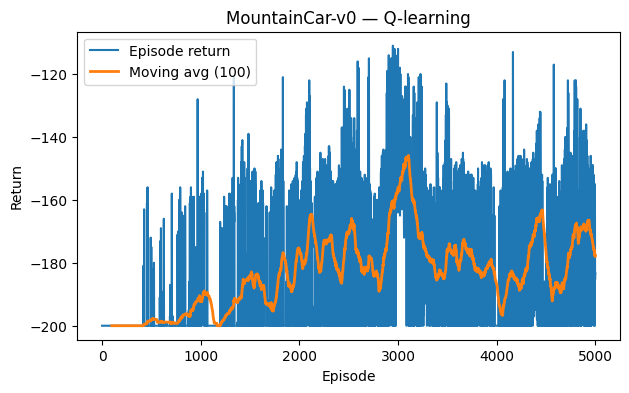

In [ ]:
# @title Plot returns
window = 100
ma = np.convolve(returns, np.ones(window)/window, mode="valid")
plt.figure(figsize=(7,4))
plt.plot(returns, label="Episode return")
plt.plot(range(window-1, len(returns)), ma, linewidth=2, label=f"Moving avg ({window})")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("MountainCar-v0 — Q-learning")
plt.legend()
plt.show()

# Roulette

In [ ]:
# @title Roulette arms (European wheel) + simulator
import numpy as np
np.random.seed(123)

class RouletteArm:
    def __init__(self, name, p_win, win_payout):
        """
        name: label for the bet (e.g., 'Red')
        p_win: probability of winning
        win_payout: net units on win (e.g., +1 for even-money, +2 for dozen, +35 for single number)
        On loss, reward = -1 (stake lost).
        """
        self.name = name
        self.p_win = p_win
        self.win_payout = win_payout

    def pull(self, rng=np.random):
        return self.win_payout if rng.rand() < self.p_win else -1.0

# European wheel: 37 pockets (0..36)
EURO = 37
arms = [
    RouletteArm("Red (18/37, 1:1)",     p_win=18/EURO, win_payout=+1.0),
    RouletteArm("Dozen (12/37, 2:1)",   p_win=12/EURO, win_payout=+2.0),
    RouletteArm("Single (1/37, 35:1)",  p_win= 1/EURO, win_payout=+35.0),
]

# Theoretical EV for all these is -1/37 ≈ -0.027027...
for arm in arms:
    ev = arm.p_win * arm.win_payout + (1 - arm.p_win) * (-1.0)
    print(f"{arm.name:24s}  EV ≈ {ev:.6f}")

Red (18/37, 1:1)          EV ≈ -0.027027
Dozen (12/37, 2:1)        EV ≈ -0.027027
Single (1/37, 35:1)       EV ≈ -0.027027


In [ ]:
# @title ε-greedy bandit trainer
import math

def train_bandit(arms, steps=100_000, eps0=1.0, eps_min=0.01, tau=5000):
    k = len(arms)
    Q = np.zeros(k, dtype=np.float64)   # value estimates per arm
    N = np.zeros(k, dtype=np.int64)     # pulls per arm
    rewards = np.zeros(steps, dtype=np.float64)
    chosen = np.zeros(steps, dtype=np.int64)

    for t in range(steps):
        # Exponential decay ε
        eps = max(eps_min, eps0 * math.exp(-t / tau))

        if np.random.rand() < eps:
            a = np.random.randint(k)
        else:
            a = int(np.argmax(Q))

        r = arms[a].pull()
        N[a] += 1
        # sample-average update
        Q[a] += (r - Q[a]) / N[a]

        rewards[t] = r
        chosen[t] = a

    return Q, N, rewards, chosen

Q, N, rewards, chosen = train_bandit(arms)
print("Estimated values (Q):")
for i, arm in enumerate(arms):
    print(f"  {arm.name:24s}  Q ≈ {Q[i]:.5f}, pulls={N[i]}")
print(f"\nAverage reward over {len(rewards)} plays: {rewards.mean():.6f}  (theory ≈ {-1/37:.6f})")

Estimated values (Q):
  Red (18/37, 1:1)          Q ≈ -0.02233, pulls=95271
  Dozen (12/37, 2:1)        Q ≈ -0.08477, pulls=1911
  Single (1/37, 35:1)       Q ≈ -0.04187, pulls=2818

Average reward over 100000 plays: -0.024070  (theory ≈ -0.027027)


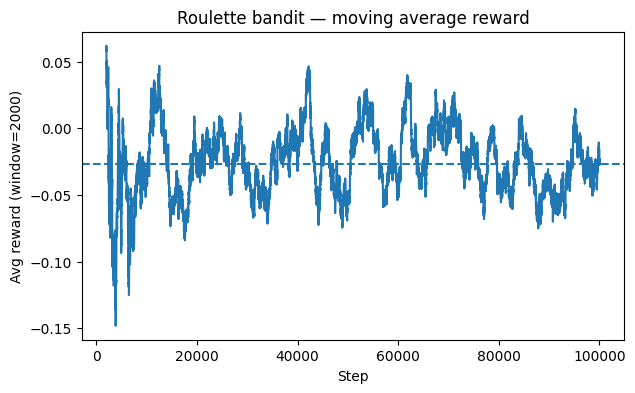

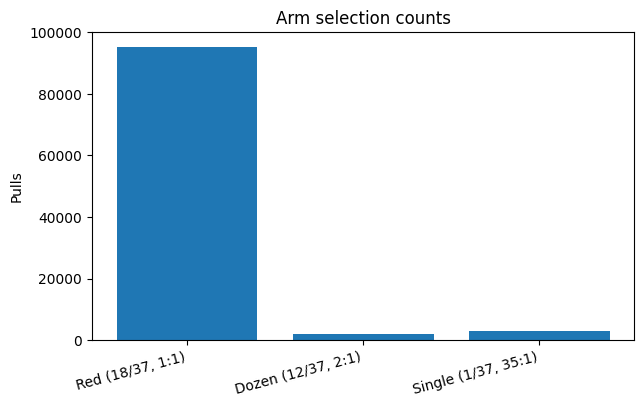

In [ ]:
# @title Plots
import matplotlib.pyplot as plt
steps = len(rewards)

# moving average of reward
win = 2000
ma = np.convolve(rewards, np.ones(win)/win, mode="valid")

plt.figure(figsize=(7,4))
plt.plot(range(win-1, steps), ma)
plt.axhline(-1/37, linestyle="--")
plt.title("Roulette bandit — moving average reward")
plt.xlabel("Step")
plt.ylabel(f"Avg reward (window={win})")
plt.show()

# arm picks
unique, counts = np.unique(chosen, return_counts=True)
plt.figure(figsize=(7,4))
plt.bar([arms[i].name for i in unique], counts)
plt.title("Arm selection counts")
plt.xticks(rotation=15, ha="right")
plt.ylabel("Pulls")
plt.show()


# Deep Reinforcement Learning (DRL) to solve the Mountain Car problem

In [ ]:
# @title Install & imports
!pip -q install gymnasium[classic-control] --upgrade
import math, random, collections, time
import numpy as np
import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng = np.random.default_rng(123)
torch.manual_seed(123)
random.seed(123)
np.random.seed(123)
print("Device:", device)

Device: cuda


In [ ]:
# @title Replay buffer & Q-network (MountainCar)
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buf = collections.deque(maxlen=capacity)
    def push(self, s, a, r, s2, d):
        self.buf.append((s, a, r, s2, d))
    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (np.stack(s), np.array(a), np.array(r, dtype=np.float32),
                np.stack(s2), np.array(d, dtype=np.float32))
    def __len__(self): return len(self.buf)

class QNet(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),     nn.ReLU(),
            nn.Linear(128, n_actions),
        )
    def forward(self, x):  # x: [B, obs_dim]
        return self.net(x)

In [ ]:
# @title Train DQN on MountainCar-v0
env = gym.make("MountainCar-v0")  # discrete actions: 0,1,2
obs_low, obs_high = env.observation_space.low, env.observation_space.high
n_actions = env.action_space.n
obs_dim = env.observation_space.shape[0]

# Scale observations to roughly [-1, 1] for stable learning
mid = (obs_high + obs_low) / 2.0
half = (obs_high - obs_low) / 2.0
def scale_obs(obs):
    return (obs - mid) / (half + 1e-8)

policy = QNet(obs_dim, n_actions).to(device)
target = QNet(obs_dim, n_actions).to(device)
target.load_state_dict(policy.state_dict())
opt = optim.Adam(policy.parameters(), lr=1e-3)
replay = ReplayBuffer(100_000)

gamma = 0.99
batch_size = 64
start_learn = 1_000       # warmup transitions before updates
target_sync = 1_000       # sync target every N updates
max_steps_per_ep = 200
episodes = 3_000

# ε schedule (steps-based)
eps_start, eps_end, eps_decay_steps = 1.0, 0.05, 50_000
def epsilon_by_step(t):
    if t >= eps_decay_steps: return eps_end
    frac = 1 - t/eps_decay_steps
    return eps_end + (eps_start - eps_end) * frac

def select_action(qvals, eps):
    if random.random() < eps:
        return random.randrange(n_actions)
    return int(torch.argmax(qvals).item())

def dqn_update(batch):
    s, a, r, s2, d = batch
    s  = torch.tensor(s,  dtype=torch.float32, device=device)
    a  = torch.tensor(a,  dtype=torch.int64,   device=device).unsqueeze(-1)
    r  = torch.tensor(r,  dtype=torch.float32, device=device).unsqueeze(-1)
    s2 = torch.tensor(s2, dtype=torch.float32, device=device)
    d  = torch.tensor(d,  dtype=torch.float32, device=device).unsqueeze(-1)

    with torch.no_grad():
        # Double-DQN target
        next_q = policy(s2)
        next_a = torch.argmax(next_q, dim=1, keepdim=True)
        next_q_target = target(s2).gather(1, next_a)
        y = r + (1 - d) * gamma * next_q_target

    q_sa = policy(s).gather(1, a)
    loss = nn.SmoothL1Loss()(q_sa, y)

    opt.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy.parameters(), 10.0)
    opt.step()
    return float(loss.item())

returns, losses = [], []
global_step, updates = 0, 0
best100 = -1e9
from collections import deque
ma100 = deque(maxlen=100)

for ep in range(1, episodes+1):
    obs, info = env.reset(seed=123 + ep)
    obs = scale_obs(obs)
    ep_ret = 0.0

    for t in range(max_steps_per_ep):
        eps = epsilon_by_step(global_step)
        qvals = policy(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0))
        act = select_action(qvals, eps)

        next_obs, r, terminated, truncated, info = env.step(act)
        done = terminated or truncated
        next_obs_s = scale_obs(next_obs)

        # store transition (use raw env reward: -1 per step until goal)
        replay.push(obs, act, r, next_obs_s, float(done))
        obs = next_obs_s
        ep_ret += r
        global_step += 1

        # learn
        if len(replay) >= start_learn:
            batch = replay.sample(batch_size)
            loss = dqn_update(batch)
            losses.append(loss)
            updates += 1
            if updates % target_sync == 0:
                target.load_state_dict(policy.state_dict())

        if done: break

    returns.append(ep_ret)
    ma100.append(ep_ret)
    if ep % 100 == 0:
        print(f"Ep {ep:4d} | ε={eps:0.3f} | avg_return(100)={np.mean(ma100):6.2f} | buffer={len(replay)}")

env.close()

Ep  100 | ε=0.620 | avg_return(100)=-200.00 | buffer=20000
Ep  200 | ε=0.240 | avg_return(100)=-200.00 | buffer=40000
Ep  300 | ε=0.050 | avg_return(100)=-200.00 | buffer=60000
Ep  400 | ε=0.050 | avg_return(100)=-200.00 | buffer=80000
Ep  500 | ε=0.050 | avg_return(100)=-199.97 | buffer=99997
Ep  600 | ε=0.050 | avg_return(100)=-186.90 | buffer=100000
Ep  700 | ε=0.050 | avg_return(100)=-172.97 | buffer=100000
Ep  800 | ε=0.050 | avg_return(100)=-177.34 | buffer=100000
Ep  900 | ε=0.050 | avg_return(100)=-156.70 | buffer=100000
Ep 1000 | ε=0.050 | avg_return(100)=-147.13 | buffer=100000
Ep 1100 | ε=0.050 | avg_return(100)=-123.84 | buffer=100000
Ep 1200 | ε=0.050 | avg_return(100)=-109.18 | buffer=100000
Ep 1300 | ε=0.050 | avg_return(100)=-117.72 | buffer=100000
Ep 1400 | ε=0.050 | avg_return(100)=-119.09 | buffer=100000
Ep 1500 | ε=0.050 | avg_return(100)=-113.38 | buffer=100000
Ep 1600 | ε=0.050 | avg_return(100)=-111.70 | buffer=100000
Ep 1700 | ε=0.050 | avg_return(100)=-121.42 |

Greedy policy avg return over 10 eval episodes: -121.30


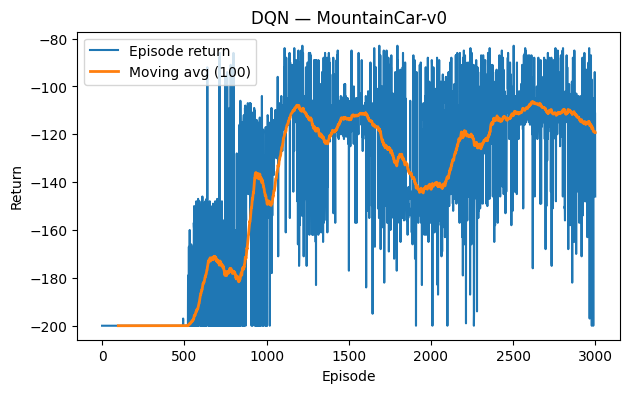

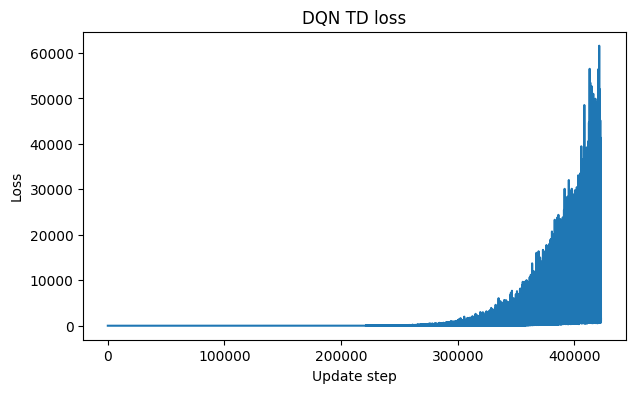

In [ ]:
# @title Evaluate greedy policy & plot curves
def eval_policy(env, policy, episodes=10):
    total = []
    for e in range(episodes):
        obs, info = env.reset(seed=999 + e)
        obs = scale_obs(obs)
        ret = 0.0
        for t in range(200):
            with torch.no_grad():
                q = policy(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0))
            a = int(torch.argmax(q).item())
            obs, r, term, trunc, _ = env.step(a)
            obs = scale_obs(obs)
            ret += r
            if term or trunc: break
        total.append(ret)
    return np.mean(total), total

env = gym.make("MountainCar-v0")
avg_ret, scores = eval_policy(env, policy, episodes=10)
env.close()
print(f"Greedy policy avg return over 10 eval episodes: {avg_ret:.2f}")

plt.figure(figsize=(7,4))
plt.plot(returns, label="Episode return")
if len(returns) >= 100:
    ma = np.convolve(returns, np.ones(100)/100, mode="valid")
    plt.plot(range(99, len(returns)), ma, linewidth=2, label="Moving avg (100)")
plt.xlabel("Episode"); plt.ylabel("Return"); plt.title("DQN — MountainCar-v0")
plt.legend(); plt.show()

if losses:
    plt.figure(figsize=(7,4))
    plt.plot(losses)
    plt.xlabel("Update step"); plt.ylabel("Loss"); plt.title("DQN TD loss")
    plt.show()

# Deep Reinforcement Learning (DRL) to solve the Roulette problem

In [ ]:
# @title Install & imports
!pip -q install gymnasium[classic-control] --upgrade
import math, random, collections, time
import numpy as np
import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng = np.random.default_rng(123)
torch.manual_seed(123)
random.seed(123)
np.random.seed(123)
print("Device:", device)

Device: cuda


In [ ]:
# @title Roulette bandit env (European wheel)
class RouletteArm:
    def __init__(self, name, p_win, win_payout):
        self.name = name
        self.p_win = float(p_win)
        self.win_payout = float(win_payout)
    def sample(self, rng):
        return self.win_payout if rng.random() < self.p_win else -1.0

class RouletteEnv:
    """
    One-step episodic bandit: reset()->obs, step(a)->(obs', reward, terminated=True, truncated=False, info)
    Observation is a constant 1D vector (no context), so the network's biases learn per-arm values.
    """
    def __init__(self, arms):
        self.arms = arms
        self.action_space = gym.spaces.Discrete(len(arms))
        self.observation_space = gym.spaces.Box(low=0.0, high=0.0, shape=(1,), dtype=np.float32)
        self.rng = random.Random(1234)
    def reset(self, seed=None):
        if seed is not None:
            self.rng.seed(seed)
        obs = np.zeros((1,), dtype=np.float32)
        return obs, {}
    def step(self, action):
        r = self.arms[action].sample(self.rng.random)
        obs = np.zeros((1,), dtype=np.float32)
        terminated, truncated = True, False
        info = {}
        return obs, float(r), terminated, truncated, info

# define arms (all EV ≈ -1/37)
EURO = 37
arms = [
    RouletteArm("Red (18/37,1:1)",    p_win=18/EURO, win_payout=+1),
    RouletteArm("Dozen (12/37,2:1)",  p_win=12/EURO, win_payout=+2),
    RouletteArm("Single (1/37,35:1)", p_win= 1/EURO, win_payout=+35),
]
envB = RouletteEnv(arms)

In [ ]:
# @title Train DQN on Roulette (bandit)
obs_dim = envB.observation_space.shape[0]
n_actions = envB.action_space.n

bandit_policy = QNet(obs_dim, n_actions).to(device)
bandit_target = QNet(obs_dim, n_actions).to(device)
bandit_target.load_state_dict(bandit_policy.state_dict())
optB = optim.Adam(bandit_policy.parameters(), lr=5e-4)
bufB = ReplayBuffer(10_000)

gammaB = 0.0                 # one-step, no future reward
batch_size = 64
start_learn = 500
sync_every = 500
episodesB = 100_000          # many short 1-step episodes
eps_start, eps_end, eps_decay_steps = 1.0, 0.01, 50_000

def eps_by_t(t):
    if t >= eps_decay_steps: return eps_end
    frac = 1 - t/eps_decay_steps
    return eps_end + (eps_start - eps_end) * frac

lossesB, rewardsB = [], []
global_t = 0
updatesB = 0

for ep in range(1, episodesB+1):
    obs, _ = envB.reset()
    eps = eps_by_t(global_t)

    with torch.no_grad():
        q = bandit_policy(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0))
    if random.random() < eps:
        a = random.randrange(n_actions)
    else:
        a = int(torch.argmax(q).item())

    obs2, r, term, trunc, _ = envB.step(a)
    bufB.push(obs, a, r, obs2, float(term))
    rewardsB.append(r)
    global_t += 1

    if len(bufB) >= start_learn:
        s, a_b, r_b, s2, d = bufB.sample(batch_size)
        s  = torch.tensor(s,  dtype=torch.float32, device=device)
        a_b= torch.tensor(a_b,dtype=torch.int64,   device=device).unsqueeze(-1)
        r_b= torch.tensor(r_b,dtype=torch.float32, device=device).unsqueeze(-1)
        s2 = torch.tensor(s2, dtype=torch.float32, device=device)
        d  = torch.tensor(d,  dtype=torch.float32, device=device).unsqueeze(-1)

        with torch.no_grad():
            # target is just r since gamma=0 or done=True
            y = r_b

        q_sa = bandit_policy(s).gather(1, a_b)
        loss = nn.SmoothL1Loss()(q_sa, y)
        optB.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(bandit_policy.parameters(), 10.0)
        optB.step()
        lossesB.append(float(loss.item()))
        updatesB += 1
        if updatesB % sync_every == 0:
            bandit_target.load_state_dict(bandit_policy.state_dict())

    # simple print every 10k steps
    if ep % 10_000 == 0:
        avg = np.mean(rewardsB[-5000:]) if len(rewardsB) >= 5000 else np.mean(rewardsB)
        print(f"t={global_t:6d} | ε={eps:0.3f} | recent avg reward ≈ {avg:0.5f}")

print("Finished.")

AttributeError: 'builtin_function_or_method' object has no attribute 'random'

In [ ]:
# @title Inspect learned action values (Q) & plots
with torch.no_grad():
    q = bandit_policy(torch.zeros(1, obs_dim, dtype=torch.float32, device=device))
print("Learned Q per arm:")
for i, arm in enumerate(arms):
    print(f"  {i}: {arm.name:22s}  Q≈{q[0,i].item():.5f}  (theory EV≈{-1/37:.5f})")

# Moving average reward
win = 2000
if len(rewardsB) >= win:
    ma = np.convolve(rewardsB, np.ones(win)/win, mode="valid")
    plt.figure(figsize=(7,4))
    plt.plot(range(win-1, len(rewardsB)), ma)
    plt.axhline(-1/37, linestyle="--")
    plt.title("Roulette DQN — moving average reward")
    plt.xlabel("Step"); plt.ylabel(f"Avg reward (window={win})")
    plt.show()

if lossesB:
    plt.figure(figsize=(7,4))
    plt.plot(lossesB)
    plt.title("Roulette DQN — TD loss")
    plt.xlabel("Update step"); plt.ylabel("Loss")
    plt.show()

Learned Q per arm:
  0: Red (18/37,1:1)         Q≈0.05849  (theory EV≈-0.02703)
  1: Dozen (12/37,2:1)       Q≈-0.03068  (theory EV≈-0.02703)
  2: Single (1/37,35:1)      Q≈0.27579  (theory EV≈-0.02703)


# RL and DRL for finding the shortest path in any user-input graph

In [ ]:
# @title Setup (imports & seeds)
!pip -q install torch --upgrade
import time, math, random, collections
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.optim as optim

random.seed(0); np.random.seed(0); torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 826.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 132.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# @title User graph (edit here)
UNDIRECTED = False  # @param {type:"boolean"}
START_NODE = 0      # @param {type:"number"}
GOAL_NODE  = 5      # @param {type:"number"}

EDGE_LIST = """
0 1 1.0
1 2 1.0
2 5 1.0
0 3 2.0
3 4 2.0
4 5 2.0
1 4 2.5
"""  # <-- Replace with your edges, one per line: u v w

# Parse
edges = []
for line in EDGE_LIST.strip().splitlines():
    u,v,w = line.strip().split()
    edges.append((int(u), int(v), float(w)))

# Build adjacency
N = max(max(u, v) for u,v,_ in edges) + 1
adj = [[] for _ in range(N)]
for u,v,w in edges:
    adj[u].append((v,w))
    if UNDIRECTED:
        adj[v].append((u,w))

print(f"Nodes: {N}, Edges: {sum(len(ns) for ns in adj)} (undirected={UNDIRECTED})")
print("Start:", START_NODE, "Goal:", GOAL_NODE)

Nodes: 6, Edges: 7 (undirected=False)
Start: 0 Goal: 5


In [ ]:
# @title Dijkstra ground truth
import heapq

def dijkstra(adj, s, g):
    N = len(adj)
    dist = [math.inf]*N
    prev = [-1]*N
    dist[s] = 0.0
    pq = [(0.0, s)]
    while pq:
        d,u = heapq.heappop(pq)
        if d!=dist[u]: continue
        if u==g: break
        for v,w in adj[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq,(nd,v))
    if dist[g] is math.inf:
        return math.inf, []
    # reconstruct
    path = []
    cur = g
    while cur!=-1:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return dist[g], path

gt_cost, gt_path = dijkstra(adj, START_NODE, GOAL_NODE)
print("Dijkstra cost:", gt_cost, "path:", gt_path)
assert gt_cost != math.inf, "Goal not reachable from start."

Dijkstra cost: 3.0 path: [0, 1, 2, 5]


In [ ]:
# @title Graph environment
class GraphEnv:
    def __init__(self, adj, start, goal, max_steps=None):
        self.adj = adj
        self.N = len(adj)
        self.start = start
        self.goal = goal
        self.max_steps = max_steps or 3*self.N
        self.reset()

    def reset(self, *, seed=None):
        if seed is not None:
            random.seed(seed); np.random.seed(seed)
        self.cur = self.start
        self.t = 0
        return self.cur

    def valid_actions(self, node=None):
        # returns list of (next_node, weight)
        node = self.cur if node is None else node
        return self.adj[node]

    def step(self, a_next):
        """a_next is the next node to move to (must be a neighbor)."""
        self.t += 1
        # find weight
        w = None
        for v, wt in self.adj[self.cur]:
            if v == a_next:
                w = wt; break
        if w is None:
            # invalid move -> heavy penalty and stay
            r = -5.0
            done = False
            return self.cur, r, done
        # move
        self.cur = a_next
        r = -float(w)
        done = (self.cur == self.goal) or (self.t >= self.max_steps)
        return self.cur, r, done

In [ ]:
# @title Tabular Q-learning
def train_qlearning(adj, start, goal, episodes=3000, gamma=0.99, eps_start=1.0, eps_end=0.05, eps_decay=0.997):
    N = len(adj)
    # We'll store Q as [N x N] (only neighbor columns get updated/used)
    Q = np.zeros((N, N), dtype=np.float32)
    env = GraphEnv(adj, start, goal)

    eps = eps_start
    returns = []
    t0 = time.time()

    for ep in range(1, episodes+1):
        s = env.reset()
        G = 0.0
        for _ in range(env.max_steps):
            neigh = env.valid_actions(s)  # list of (v,w)
            if not neigh: break
            if np.random.rand() < eps:
                a_next = random.choice(neigh)[0]
            else:
                # pick neighbor with best Q
                a_next = max(neigh, key=lambda vw: Q[s, vw[0]])[0]
            s2, r, done = env.step(a_next)

            # Q update (max over next neighbors)
            if done or (not env.valid_actions(s2)):
                target = r
            else:
                maxq = max(Q[s2, v] for v,_ in env.valid_actions(s2))
                target = r + gamma * maxq
            Q[s, a_next] += 0.1 * (target - Q[s, a_next])

            s = s2
            G += r
            if done: break

        returns.append(G)
        eps = max(eps_end, eps*eps_decay)
        if ep % 500 == 0:
            print(f"[Tabular] Ep {ep:4d} | ε={eps:.3f} | recent avg return={np.mean(returns[-100:]):.3f}")

    wall = time.time() - t0
    return Q, returns, wall

def eval_policy_q(adj, Q, start, goal, trials=20):
    env = GraphEnv(adj, start, goal)
    succ, steps, costs = 0, [], []
    for _ in range(trials):
        s = env.reset()
        G = 0.0; L = 0
        for _ in range(env.max_steps):
            neigh = env.valid_actions(s)
            if not neigh: break
            a_next = max(neigh, key=lambda vw: Q[s, vw[0]])[0]
            s, r, done = env.step(a_next)
            G += r; L += 1
            if done: break
        if s == goal:
            succ += 1; steps.append(L); costs.append(-G)
    sr = succ / trials
    return sr, (np.mean(steps) if steps else np.nan), (np.mean(costs) if costs else np.nan)

In [ ]:
# @title DQN (masked actions)
class QNet(nn.Module):
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 128), nn.ReLU(),
            nn.Linear(128, 128),  nn.ReLU(),
            nn.Linear(128, n_out)
        )
    def forward(self, x):
        return self.net(x)

class Replay:
    def __init__(self, cap=100_000): self.buf = collections.deque(maxlen=cap)
    def push(self, s,a,r,s2,d): self.buf.append((s,a,r,s2,d))
    def sample(self, B):
        batch = random.sample(self.buf, B)
        s,a,r,s2,d = zip(*batch)
        return np.stack(s), np.array(a), np.array(r, np.float32), np.stack(s2), np.array(d, np.float32)
    def __len__(self): return len(self.buf)

def one_hot(i, N):
    v = np.zeros(N, np.float32); v[i] = 1.0; return v

def select_action_masked(policy, s_node, adj, eps):
    if random.random() < eps:
        neigh = adj[s_node]
        return random.choice(neigh)[0] if neigh else s_node
    with torch.no_grad():
        q = policy(torch.tensor(one_hot(s_node, len(adj)), device=device).unsqueeze(0))
    q = q[0].cpu().numpy()
    mask = np.full_like(q, -1e9, dtype=np.float32)
    for v,_ in adj[s_node]:
        mask[v] = q[v]
    return int(np.argmax(mask))

def train_dqn(adj, start, goal, episodes=4000, gamma=0.99, lr=1e-3,
              eps_start=1.0, eps_end=0.05, eps_decay_steps=50_000,
              batch_size=64, start_learn=1000, sync_every=1000):
    N = len(adj)
    env = GraphEnv(adj, start, goal)
    policy = QNet(N, N).to(device)
    target = QNet(N, N).to(device); target.load_state_dict(policy.state_dict())
    opt = optim.Adam(policy.parameters(), lr=lr)
    buf = Replay(100_000)

    def eps_by_step(t):
        if t >= eps_decay_steps: return eps_end
        frac = 1 - t/eps_decay_steps
        return eps_end + (eps_start-eps_end)*frac

    returns, losses = [], []
    t0 = time.time()
    global_t, updates = 0, 0

    for ep in range(1, episodes+1):
        s = env.reset()
        G = 0.0
        for _ in range(env.max_steps):
            eps = eps_by_step(global_t)
            a = select_action_masked(policy, s, adj, eps)
            s2, r, done = env.step(a)
            buf.push(one_hot(s,N), a, r, one_hot(s2,N), float(done))
            s = s2; G += r; global_t += 1

            if len(buf) >= start_learn:
                S, A, R, S2, D = buf.sample(batch_size)
                S  = torch.tensor(S,  dtype=torch.float32, device=device)
                A  = torch.tensor(A,  dtype=torch.int64,   device=device).unsqueeze(-1)
                R  = torch.tensor(R,  dtype=torch.float32, device=device).unsqueeze(-1)
                S2 = torch.tensor(S2, dtype=torch.float32, device=device)
                D  = torch.tensor(D,  dtype=torch.float32, device=device).unsqueeze(-1)

                with torch.no_grad():
                    # Double-DQN target with masking on S2
                    q_next = policy(S2)              # [B,N]
                    a_next = torch.argmax(q_next, dim=1, keepdim=True)  # [B,1]
                    q_targ = target(S2).gather(1, a_next)
                    Y = R + (1-D) * gamma * q_targ

                q_sa = policy(S).gather(1, A)
                loss = nn.SmoothL1Loss()(q_sa, Y)
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(policy.parameters(), 10.0)
                opt.step()
                losses.append(float(loss.item()))
                updates += 1
                if updates % sync_every == 0:
                    target.load_state_dict(policy.state_dict())

            if done: break

        returns.append(G)
        if ep % 500 == 0:
            print(f"[DQN] Ep {ep:4d} | ε={eps_by_step(global_t):.3f} | recent avg return={np.mean(returns[-100:]):.3f}")

    wall = time.time() - t0
    return policy, returns, losses, wall

def eval_policy_dqn(adj, policy, start, goal, trials=20):
    env = GraphEnv(adj, start, goal)
    succ, steps, costs = 0, [], []
    for _ in range(trials):
        s = env.reset()
        G = 0.0; L = 0
        for _ in range(env.max_steps):
            a = select_action_masked(policy, s, adj, eps=0.0)
            s, r, done = env.step(a)
            G += r; L += 1
            if done: break
        if s == goal:
            succ += 1; steps.append(L); costs.append(-G)
    sr = succ / trials
    return sr, (np.mean(steps) if steps else np.nan), (np.mean(costs) if costs else np.nan)

In [ ]:
# @title Train RL & DRL and compare
# RL (Tabular)
Q, rl_returns, rl_time = train_qlearning(adj, START_NODE, GOAL_NODE, episodes=3000)
rl_sr, rl_steps, rl_cost = eval_policy_q(adj, Q, START_NODE, GOAL_NODE)

# DRL (DQN)
policy, dqn_returns, dqn_losses, dqn_time = train_dqn(adj, START_NODE, GOAL_NODE, episodes=4000)
dqn_sr, dqn_steps, dqn_cost = eval_policy_dqn(adj, policy, START_NODE, GOAL_NODE)

# Build comparison
df = pd.DataFrame([
    {
        "Method": "Tabular Q-learning",
        "Episodes": len(rl_returns),
        "Train wall-time (s)": round(rl_time, 3),
        "Eval success rate": rl_sr,
        "Avg steps (eval)": rl_steps,
        "Avg path cost (eval)": rl_cost,
        "Shortest cost (Dijkstra)": gt_cost,
        "Gap vs. optimal": (None if rl_cost is np.nan else rl_cost - gt_cost)
    },
    {
        "Method": "DQN",
        "Episodes": len(dqn_returns),
        "Train wall-time (s)": round(dqn_time, 3),
        "Eval success rate": dqn_sr,
        "Avg steps (eval)": dqn_steps,
        "Avg path cost (eval)": dqn_cost,
        "Shortest cost (Dijkstra)": gt_cost,
        "Gap vs. optimal": (None if dqn_cost is np.nan else dqn_cost - gt_cost)
    }
])
df

[Tabular] Ep  500 | ε=0.223 | recent avg return=-3.585
[Tabular] Ep 1000 | ε=0.050 | recent avg return=-3.025
[Tabular] Ep 1500 | ε=0.050 | recent avg return=-3.145
[Tabular] Ep 2000 | ε=0.050 | recent avg return=-3.240
[Tabular] Ep 2500 | ε=0.050 | recent avg return=-3.080
[Tabular] Ep 3000 | ε=0.050 | recent avg return=-3.000
[DQN] Ep  500 | ε=0.972 | recent avg return=-5.030
[DQN] Ep 1000 | ε=0.943 | recent avg return=-5.205
[DQN] Ep 1500 | ε=0.914 | recent avg return=-5.015
[DQN] Ep 2000 | ε=0.886 | recent avg return=-4.980


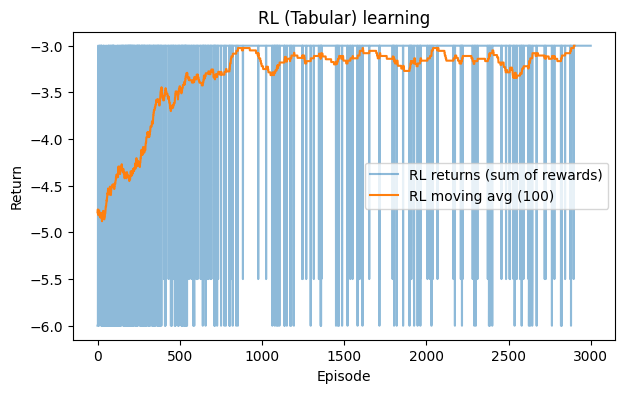

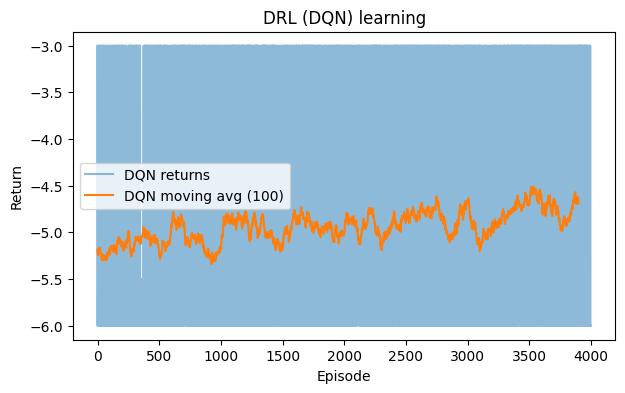

In [ ]:
# @title Learning curves (optional)
import matplotlib.pyplot as plt

def moving_avg(x, w=100):
    if len(x)<w: return np.array([])
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure(figsize=(7,4))
plt.plot(rl_returns, alpha=0.5, label="RL returns (sum of rewards)")
ma = moving_avg(rl_returns);
if len(ma): plt.plot(range(len(ma)), ma, label="RL moving avg (100)")
plt.title("RL (Tabular) learning"); plt.xlabel("Episode"); plt.ylabel("Return")
plt.legend(); plt.show()

plt.figure(figsize=(7,4))
plt.plot(dqn_returns, alpha=0.5, label="DQN returns")
ma = moving_avg(dqn_returns);
if len(ma): plt.plot(range(len(ma)), ma, label="DQN moving avg (100)")
plt.title("DRL (DQN) learning"); plt.xlabel("Episode"); plt.ylabel("Return")
plt.legend(); plt.show()